In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Recommended IND"

X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = HistGradientBoostingClassifier(
    learning_rate=0.05,      #  tuned
    max_depth=6,             #  controls complexity
    max_iter=200,            # boosting rounds
    early_stopping=True,     #  important
    validation_fraction=0.1,
    n_iter_no_change=10,     # stop if no improvement
    random_state=42
)

In [4]:
model.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

In [5]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9382716049382716
F1 Score: 0.9620617477760335


In [6]:
learning_rates = [0.01, 0.05]
depths = [4, 6]

best_score = 0
best_params = {}

for lr in learning_rates:
    for depth in depths:
        
        temp_model = HistGradientBoostingClassifier(
            learning_rate=lr,
            max_depth=depth,
            early_stopping=True,
            random_state=42
        )
        
        temp_model.fit(X_train, y_train)
        y_pred = temp_model.predict(X_test)
        
        f1 = f1_score(y_test, y_pred)
        
        if f1 > best_score:
            best_score = f1
            best_params = {"lr": lr, "depth": depth}

print("Best Params:", best_params)
print("Best F1:", best_score)

Best Params: {'lr': 0.05, 'depth': 4}
Best F1: 0.9616542337390394


Task 2: Train and evaluate an XGBoost model by performing hyperparameter tuning with Bayesian Optimization, analyzing feature interactions, and visualizing model performance using SHAP summary plots.

In [7]:
pip install xgboost scikit-optimize shap


  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 824.7 kB/s eta 0:02:03
   ---------------------------------------- 0.5/101.7 MB 824.7 kB/s eta 0:02:03
   ---------------------------------------- 0.8/101.7 MB 729.6 kB/s eta 0:02:19
   ---------------------------------------- 1.0/101.7 MB 845.1 kB/s eta 0:02:00
   ---------------------------------------- 1.0/101.7 MB 845.1 kB/s eta 0:02:00
    --------------------------------------- 1.6/101.7 MB 966.8 kB/s eta 0:01:44
    --------------------------------------- 1.8/101.7 MB 1.0 MB/s eta 0:01:38
    --------------------------------------- 2.4/101.7 MB 1.2 MB/s eta 0:01:22
   - -------------------------------------- 3.1/101.7 MB 1.5 MB/s eta 0:01:07
 

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from xgboost import XGBClassifier

df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Recommended IND"

X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from skopt import BayesSearchCV

# Small sample (speed)
X_small = X_train.sample(3000, random_state=42)
y_small = y_train.loc[X_small.index]

param_space = {
    "n_estimators": (50, 150),
    "max_depth": (3, 8),
    "learning_rate": (0.01, 0.2, "log-uniform"),
    "subsample": (0.5, 1.0),
    "colsample_bytree": (0.5, 1.0)
}

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

bayes = BayesSearchCV(
    xgb,
    param_space,
    n_iter=10,      
    cv=2,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

bayes.fit(X_small, y_small)

print("Best Params:", bayes.best_params_)

c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:35:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: OrderedDict({'colsample_bytree': 0.8670140089927842, 'learning_rate': 0.16678162679202435, 'max_depth': 4, 'n_estimators': 69, 'subsample': 0.9002516157283724})


In [10]:
best_model = bayes.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:35:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9344401873137506
F1 Score: 0.9597069597069597


                    feature  importance
3                    Rating    0.542908
60   rating_sentiment_label    0.176042
10                    PCA_1    0.023547
13                    PCA_4    0.006539
14                    PCA_5    0.006307
59          sentiment_score    0.005963
4   Positive Feedback Count    0.005935
29                   PCA_20    0.005713
40                   PCA_31    0.005696
11                    PCA_2    0.005542


<Figure size 600x400 with 0 Axes>

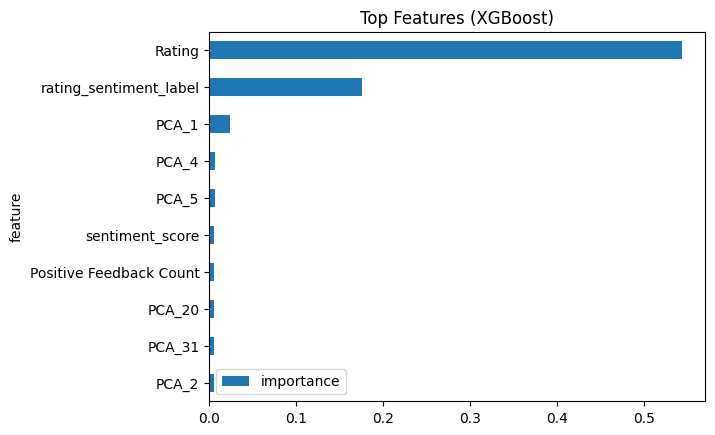

In [11]:
import matplotlib.pyplot as plt

importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_df.head(10))

plt.figure(figsize=(6,4))
feat_df.head(10).plot(kind="barh", x="feature", y="importance")
plt.gca().invert_yaxis()
plt.title("Top Features (XGBoost)")
plt.show()

c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


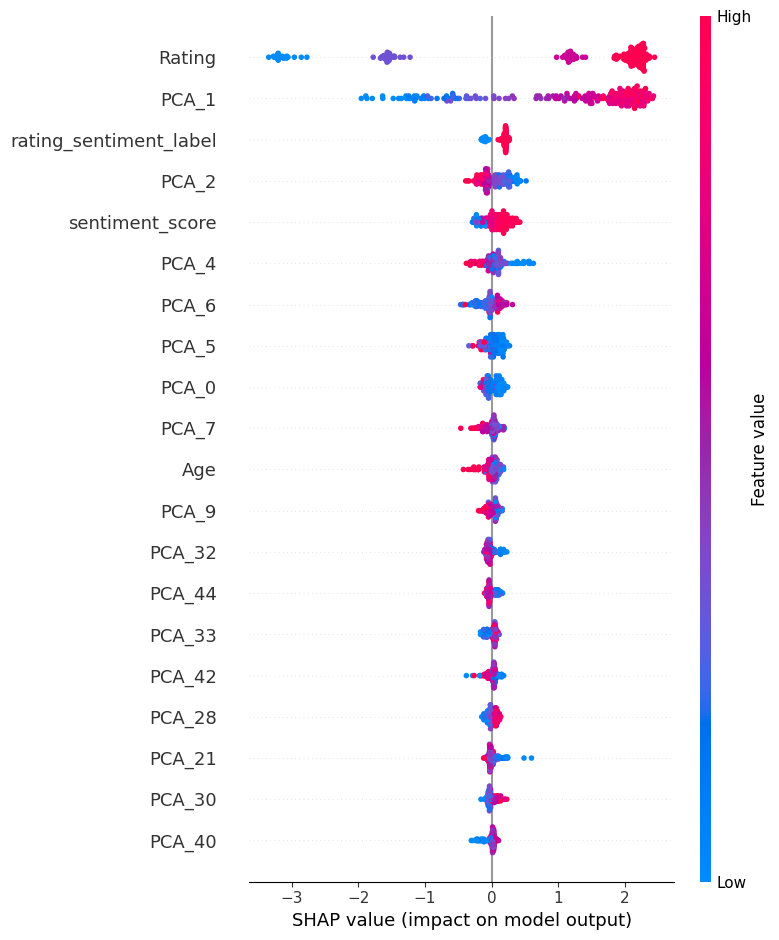

In [13]:
import shap

# Small sample (IMPORTANT)
X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

Task 3: Use SHAP values to interpret model predictions by generating global and local explanations, identifying the most influential features for different classes, and comparing SHAP results across multiple models for deeper interpretability.

🔹 Global SHAP Summary


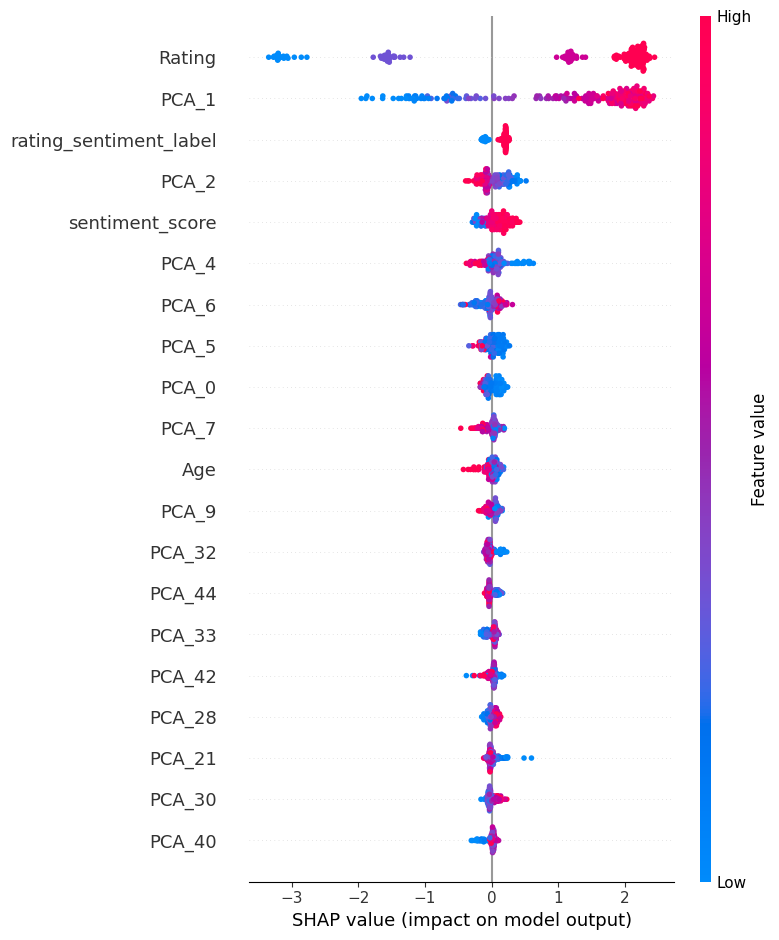

🔹 Feature Importance (Bar)


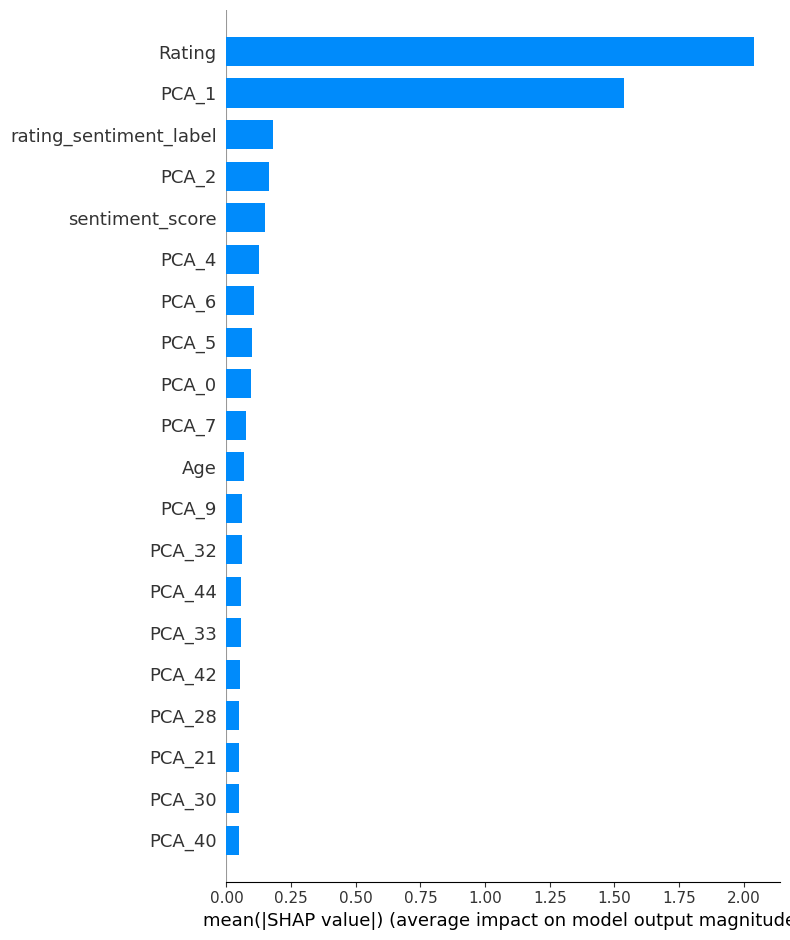

🔹 Local Explanation (Single Prediction)


🔹 Feature Interaction


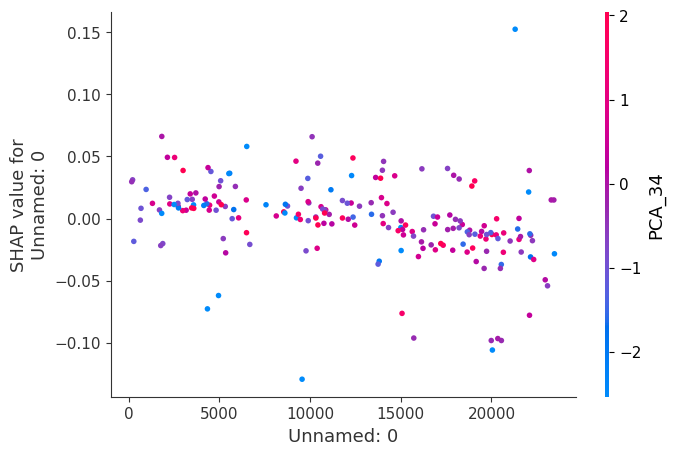

🔹 Compare with Random Forest
XGBoost SHAP


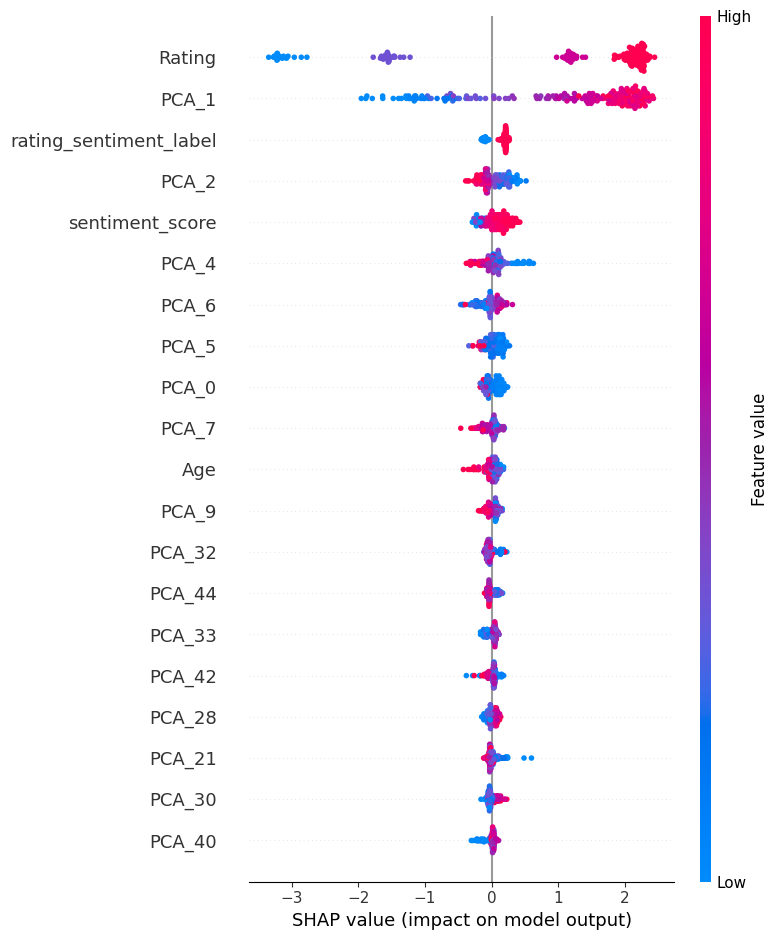

Random Forest SHAP


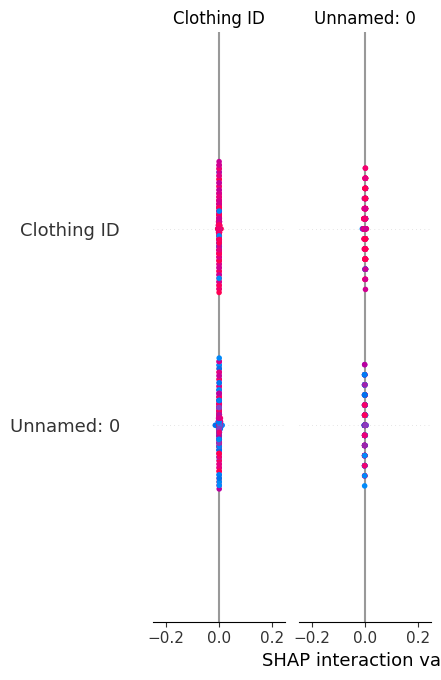

In [20]:
# =========================================
# SHAP INTERPRETATION (ALL STEPS)
# =========================================

import shap
import pandas as pd
import numpy as np

# -----------------------------
# STEP 0: Sample Data
# -----------------------------
X_sample = X_test.sample(200, random_state=42)

# -----------------------------
# STEP 1: XGBOOST EXPLAINER
# -----------------------------
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# -----------------------------
# STEP 2: GLOBAL SUMMARY
# -----------------------------
print("🔹 Global SHAP Summary")
shap.summary_plot(shap_values, X_sample)

# -----------------------------
# STEP 3: FEATURE IMPORTANCE BAR
# -----------------------------
print("🔹 Feature Importance (Bar)")
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# -----------------------------
# STEP 4: LOCAL EXPLANATION
# -----------------------------
print("🔹 Local Explanation (Single Prediction)")
i = 0

shap.initjs()   # required for visualization
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_sample.iloc[i]
)

# -----------------------------
# STEP 5: DEPENDENCE PLOT
# -----------------------------
print("🔹 Feature Interaction")

# pick first feature
feature_name = X_sample.columns[0]

shap.dependence_plot(
    feature_name,
    shap_values,
    X_sample
)
print("🔹 Compare with Random Forest")

# Ensure model exists
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

explainer_rf = shap.TreeExplainer(best_rf)
shap_rf = explainer_rf.shap_values(X_sample)

print("XGBoost SHAP")
shap.summary_plot(shap_values, X_sample)

print("Random Forest SHAP")
shap.summary_plot(shap_rf, X_sample)

Task 4: Perform feature selection and retrain models by using Recursive Feature Elimination (RFE), permutation importance, and principal component analysis (PCA) to reduce dimensionality while maintaining predictive accuracy.

RFE (Feature Selection)


In [16]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Use smaller data for speed
X_small = X_train.sample(3000, random_state=42)
y_small = y_train.loc[X_small.index]

model = RandomForestClassifier(n_estimators=50, random_state=42)

rfe = RFE(model, n_features_to_select=20)   # select top 20 features
rfe.fit(X_small, y_small)

selected_features = X.columns[rfe.support_]

print("Selected Features:", list(selected_features))

Selected Features: ['Clothing ID', 'Rating', 'engagement_scaled', 'PCA_0', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_8', 'PCA_9', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_19', 'PCA_25', 'PCA_35', 'PCA_41', 'sentiment_score', 'rating_sentiment_label']


Permutation Importance

In [17]:
from sklearn.inspection import permutation_importance

# Train model on full data
model.fit(X_train, y_train)

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

print(perm_df.head(10))

                    feature  importance
3                    Rating    0.019625
10                    PCA_1    0.010558
60   rating_sentiment_label    0.006513
59          sentiment_score    0.002937
13                    PCA_4    0.001831
21                   PCA_12    0.001788
11                    PCA_2    0.001660
4   Positive Feedback Count    0.001533
26                   PCA_17    0.001533
2                       Age    0.001490


PCA (Dimensionality Reduction)

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=50)   # reduce dimensions

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (23486, 61)
Reduced shape: (23486, 50)


Retrain Model on PCA Data

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = RandomForestClassifier(n_estimators=50, random_state=42)

model_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

print("F1 Score (PCA Model):", f1_score(y_test_pca, y_pred_pca))

F1 Score (PCA Model): 0.9611177013312244


Task 5: Compare different models' performance in a summary table by aggregating evaluation metrics (accuracy, F1-score, ROC-AUC, training time), ranking models based on performance trade-offs, and visualizing comparisons through heatmaps or radar charts.

In [21]:
import pandas as pd
import numpy as np
import time

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
#Create Evaluation Function

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    start = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    return {
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC-AUC": roc,
        "Training Time": train_time
    }

Create Evaluation Function

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

In [27]:
results = []

# Logistic
results.append(evaluate_model("Logistic", pipeline, X_train, X_test, y_train, y_test))

# Random Forest
results.append(evaluate_model("Random Forest", best_rf, X_train, X_test, y_train, y_test))

# Gradient Boosting
results.append(evaluate_model("Gradient Boosting", model, X_train, X_test, y_train, y_test))

# XGBoost
results.append(evaluate_model("XGBoost", best_model, X_train, X_test, y_train, y_test))

In [26]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

Create Summary Table

In [29]:
results_df = pd.DataFrame(results)

# Ranking (based on F1 Score)
results_df["Rank"] = results_df["F1 Score"].rank(ascending=False)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

               Model  Accuracy  F1 Score   ROC-AUC  Training Time  Rank
2  Gradient Boosting  0.936356  0.960601  0.973843       8.053030   1.0
3            XGBoost  0.934653  0.959895  0.976665       3.703056   2.0
1      Random Forest  0.934866  0.959758  0.977304       3.482388   3.0
0           Logistic  0.931460  0.956755  0.978823       1.408355   4.0


Heatmap Visualization

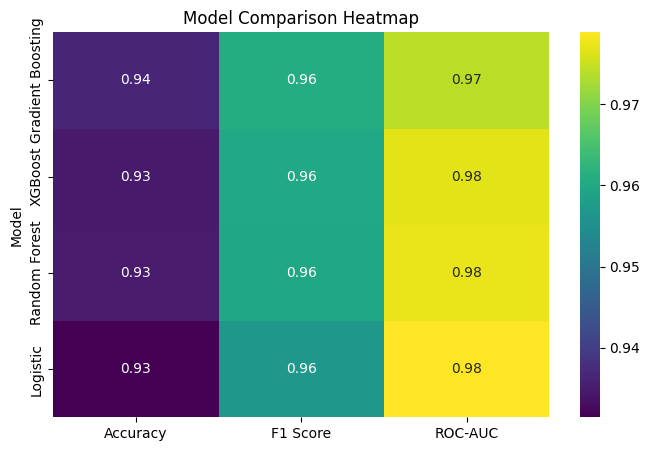

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    results_df.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]],
    annot=True,
    cmap="viridis"
)

plt.title("Model Comparison Heatmap")
plt.show()

Radar Chart

In [31]:
import plotly.graph_objects as go

metrics = ["Accuracy", "F1 Score", "ROC-AUC"]

fig = go.Figure()

for i, row in results_df.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row[m] for m in metrics],
        theta=metrics,
        fill='toself',
        name=row["Model"]
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Model Comparison Radar Chart"
)

fig.show()